# Insect Identification & Classification Project

This is an image classification problem of 291 species of Insects using  63,364 images from the Natural History Museum London

Source: https://zenodo.org/record/3549369#.XvI_jMfVLIU

[Data Set of 120 Insect Species for Classification projects]
(https://www.kaggle.com/general/164015)

[Insect identification from habitus images]
(https://www.kaggle.com/datasets/kmldas/insect-identification-from-habitus-images?resource=download)


**Each folder is named as the gbif id number**. 

E.g. Carabus problematicus is 4470555: https://www.gbif.org/species/4470555

To get json respose: https://api.gbif.org/v1/species/8378220

#  Import Libraries

In [56]:
import os
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

import random
import time

from torch.utils.data import Dataset, random_split, DataLoader
from PIL import Image
import torchvision.models as models
from tqdm.notebook import tqdm
import torchvision.transforms as T

from sklearn.metrics import f1_score
import torch.nn.functional as F
import torch.nn as nn
from torchvision.utils import make_grid


# Read the data

In [57]:
# Load the paths to the images in a directory

def load_images_from_folder(folder: str, only_path: bool = False, label: str = ""):
    if only_path == False:
        images = []
        file_name=[]
        for filename in os.listdir(folder):
            img = plt.imread(os.path.join(folder,filename))
            
            if img is not None:
                end=filename.find(".")
                file_name.append(filename[0:end])
                images.append(img)
                
        return images, file_name
    else:
        path = []
        for filename in os.listdir(folder):
            img_path = os.path.join(folder,filename)
            if img_path is not None:
                path.append([label,img_path])
        return path

# Set up the data and a label dictionary

In [58]:
# Load the paths on the images
images = []
path = "../data/image/insect-cls-database/"
for f in os.listdir(path):
    if "jpg" in os.listdir(path+f)[0]:
        images += load_images_from_folder(path+f,True,label = f)
      
    else: 
        for d in os.listdir(path+f):
            images += load_images_from_folder(path+f+"/"+d,True,label = f)
            
                        
# Create a dataframe with the paths and the label for each insect
df1 = pd.DataFrame(images, columns = ["insect_gbif", "path_img"])

file_name=[]
for i in range(len(df1["path_img"])):
    temp=df1.path_img[i].split('/')[-1].split('.')[0]
    file_name.append(temp)
file_name

df1['file_name'] = file_name
display(df1.describe())

display(df1)


,insect_gbif,path_img,file_name
count,63365,63365,63365
unique,291,63365,63365
top,9364935,../data/image/insect-cls-database/1036154/d090...,d090s0264
freq,888,1,1


,insect_gbif,path_img,file_name
0,1036154,../data/image/insect-cls-database/1036154/d090...,d090s0264
1,1036154,../data/image/insect-cls-database/1036154/d090...,d090s0474
2,1036154,../data/image/insect-cls-database/1036154/d090...,d090s0505
3,1036154,../data/image/insect-cls-database/1036154/d090...,d090s0163
4,1036154,../data/image/insect-cls-database/1036154/d090...,d090s0316
...,...,...,...
63360,8423772,../data/image/insect-cls-database/8423772/d119...,d119s0083
63361,8423772,../data/image/insect-cls-database/8423772/d119...,d119s0029
63362,8423772,../data/image/insect-cls-database/8423772/d119...,d119s0041
63363,8423772,../data/image/insect-cls-database/8423772/d119...,d119s0214


In [59]:
labels = df1["insect_gbif"].unique()

labels_dict = dict(zip(range(len(labels)),labels))
list(labels_dict.items())[:10] 

[(0, '1036154'),
 (1, '9581584'),
 (2, '4476667'),
 (3, '8417764'),
 (4, '5756021'),
 (5, '4471235'),
 (6, '5757308'),
 (7, '4480485'),
 (8, '1036958'),
 (9, '6097900')]

## label gbif to species name

In [63]:
import requests
from dataclasses import dataclass, field
from typing import Optional, Dict, List
import json
import functional as pyfun

print(labels[:5])

@dataclass
#class InsectInfo(frozen=True):
class InsectInfo():
    species: str = field()
    canonical_name: str = field()
    vernacular_name: str = field()
    full_description: Dict = field(hash=False, repr=False)

def retrieve_insect_info(gbif_id: str) -> Exception | Dict:
    GBIF_API_URL = 'https://api.gbif.org/v1/species/'
    req_url = f'{GBIF_API_URL}{gbif_id}'
    print(f'request url: {req_url}')
    gbif_res = requests.get(req_url)

    match gbif_res.status_code:
        case 200:
            tmp = gbif_res.json()
            print(type(tmp))
            #print(f'species: {species}, canonical name: {canonical_name}, vernacular name: {vernacular_name}')
            return tmp
        case code if code >=400 and code <= 451:
            return Exception(f'url {req_url} not found')
        case _:
            return Exception(f'response code: {gbif_res.status_code}')

def extract_insect_info(content: Dict) -> InsectInfo:
    species = content['species']
    canonical_name = content['canonicalName']
    vernacular_name = content['vernacularName']
    insect_info = InsectInfo(species, canonical_name, vernacular_name, content)

    return insect_info


def inset_gbif_test():
    gbif_id = labels[0]
    # gbif_id = '123a' # non-exist id
    info = retrieve_insect_info(gbif_id)
    #print(info)
    insect = extract_insect_info(info)
    print(insect)


inset_gbif_test()



['1036154' '9581584' '4476667' '8417764' '5756021']
request url: https://api.gbif.org/v1/species/1036154
<class 'dict'>
InsectInfo(species='Bembidion guttula', canonical_name='Bembidion guttula', vernacular_name='Ground beetle')


# Exlporatory Data Analysis (EDA)

Let us look at the data and make some initial conclusions

In [6]:
num_images = len(df1["insect_gbif"])
print('Number of images are:', num_images)
no_labels=len(labels)
print('Number of insect species are:', no_labels)

Number of images are: 63364
Number of insect species are: 291


Are images equally distributed between different insect species?

Let's plot a graph and see!

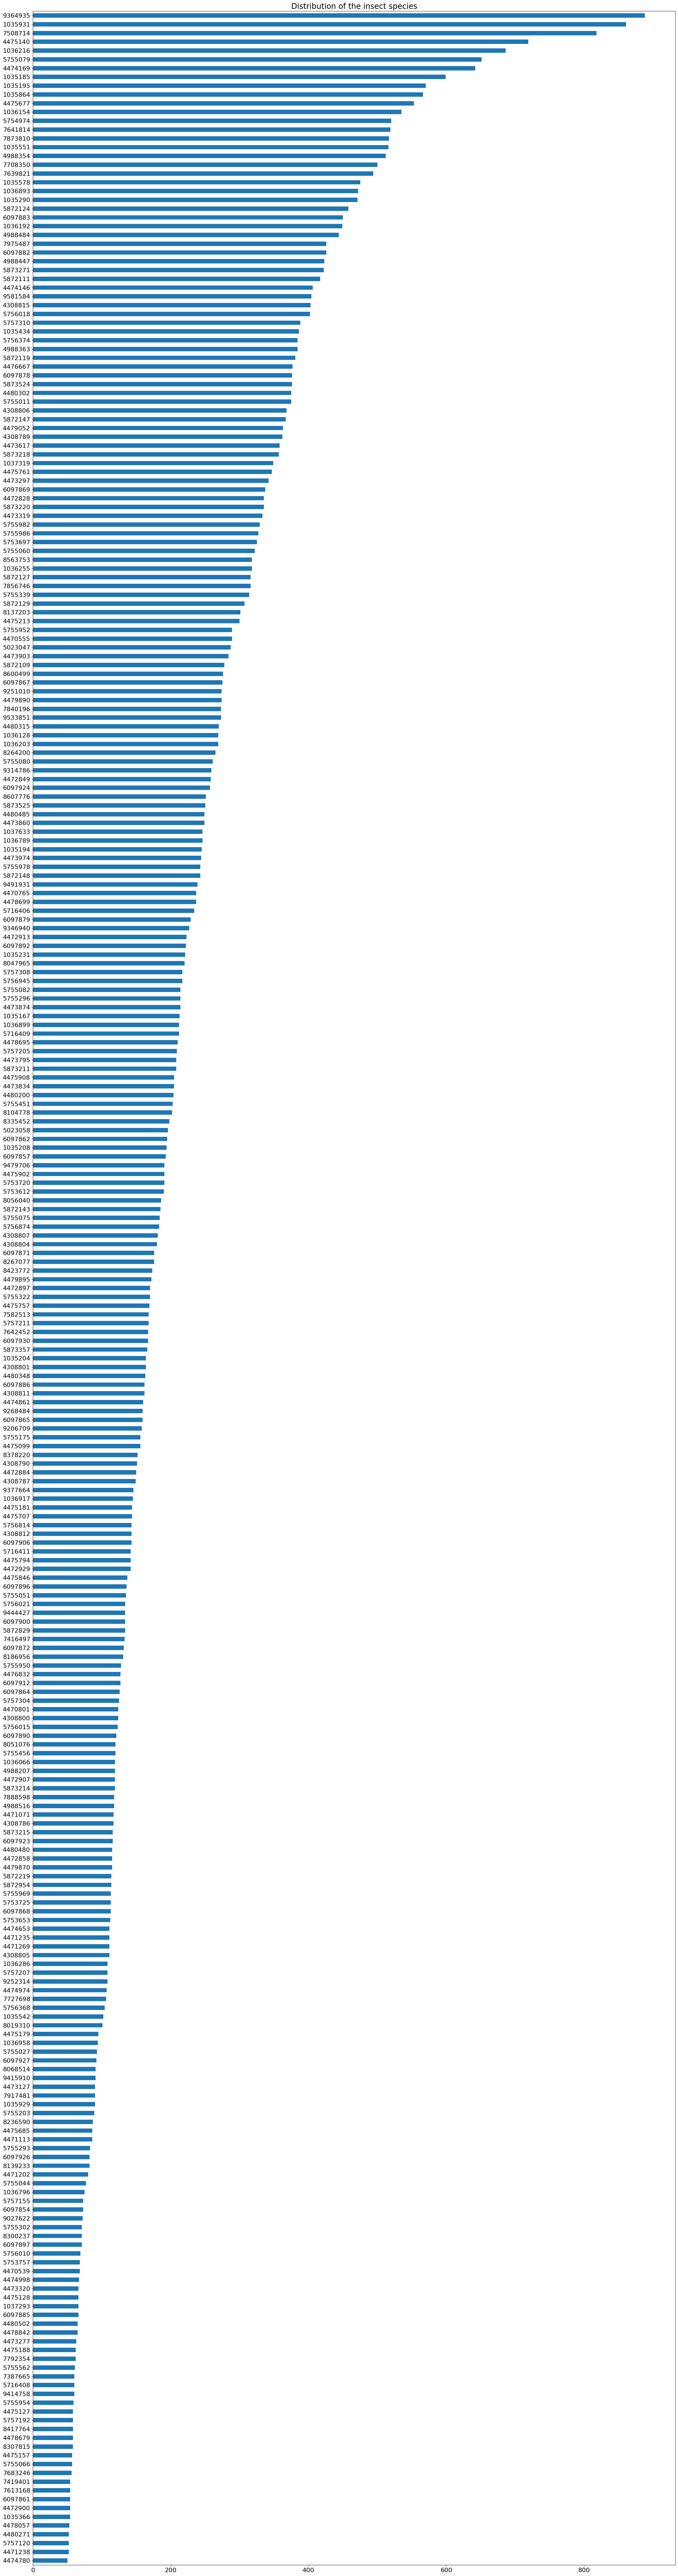

In [7]:
bar = df1["insect_gbif"].value_counts(ascending=True).plot.barh(figsize = (30,120))
plt.title("Distribution of the insect species", fontsize = 20)
bar.tick_params(labelsize=16)
plt.show()

lets also make a table.. may be better as there are 200+ species

In [8]:
df1["insect_gbif"].value_counts()

9364935    888
1035931    861
7508714    818
4475140    719
1036216    686
          ... 
4478057     53
4471238     52
4480271     52
5757120     52
4474780     50
Name: insect_gbif, Length: 291, dtype: int64

It is a very unbalanced data. Some insect species have only 50 images, while others have 888!

# Split data into test, train and validation

In [9]:
train, validate, test = np.split(df1.sample(frac=1), [int(.6*len(df1)), int(.8*len(df1))])

display(train.describe())
display(validate.describe())
display(test.describe())

,insect_gbif,path_img,file_name
count,38018,38018,38018
unique,291,38018,38018
top,9364935,../data/image/insect-cls-database/5023047/d045...,d045s0202
freq,528,1,1


,insect_gbif,path_img,file_name
count,12673,12673,12673
unique,291,12673,12673
top,9364935,../data/image/insect-cls-database/4473834/d030...,d030s0047
freq,179,1,1


,insect_gbif,path_img,file_name
count,12673,12673,12673
unique,291,12673,12673
top,1035931,../data/image/insect-cls-database/5755079/d145...,d145s0217
freq,189,1,1


Some may prefer only test abd validation

you may combine two data sets- this will result in only train and validation set

comment or delete the below code if you want three sets of data

In [11]:
df=train.append(test, ignore_index=True)
df.describe()

/tmp/ipykernel_27382/2897844569.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df=train.append(test, ignore_index=True)


,insect_gbif,path_img,file_name
count,50691,50691,50691
unique,291,50691,50691
top,9364935,../data/image/insect-cls-database/5023047/d045...,d045s0202
freq,709,1,1


# Image Analysis

Let us display 20 picture of the dataset with their labels

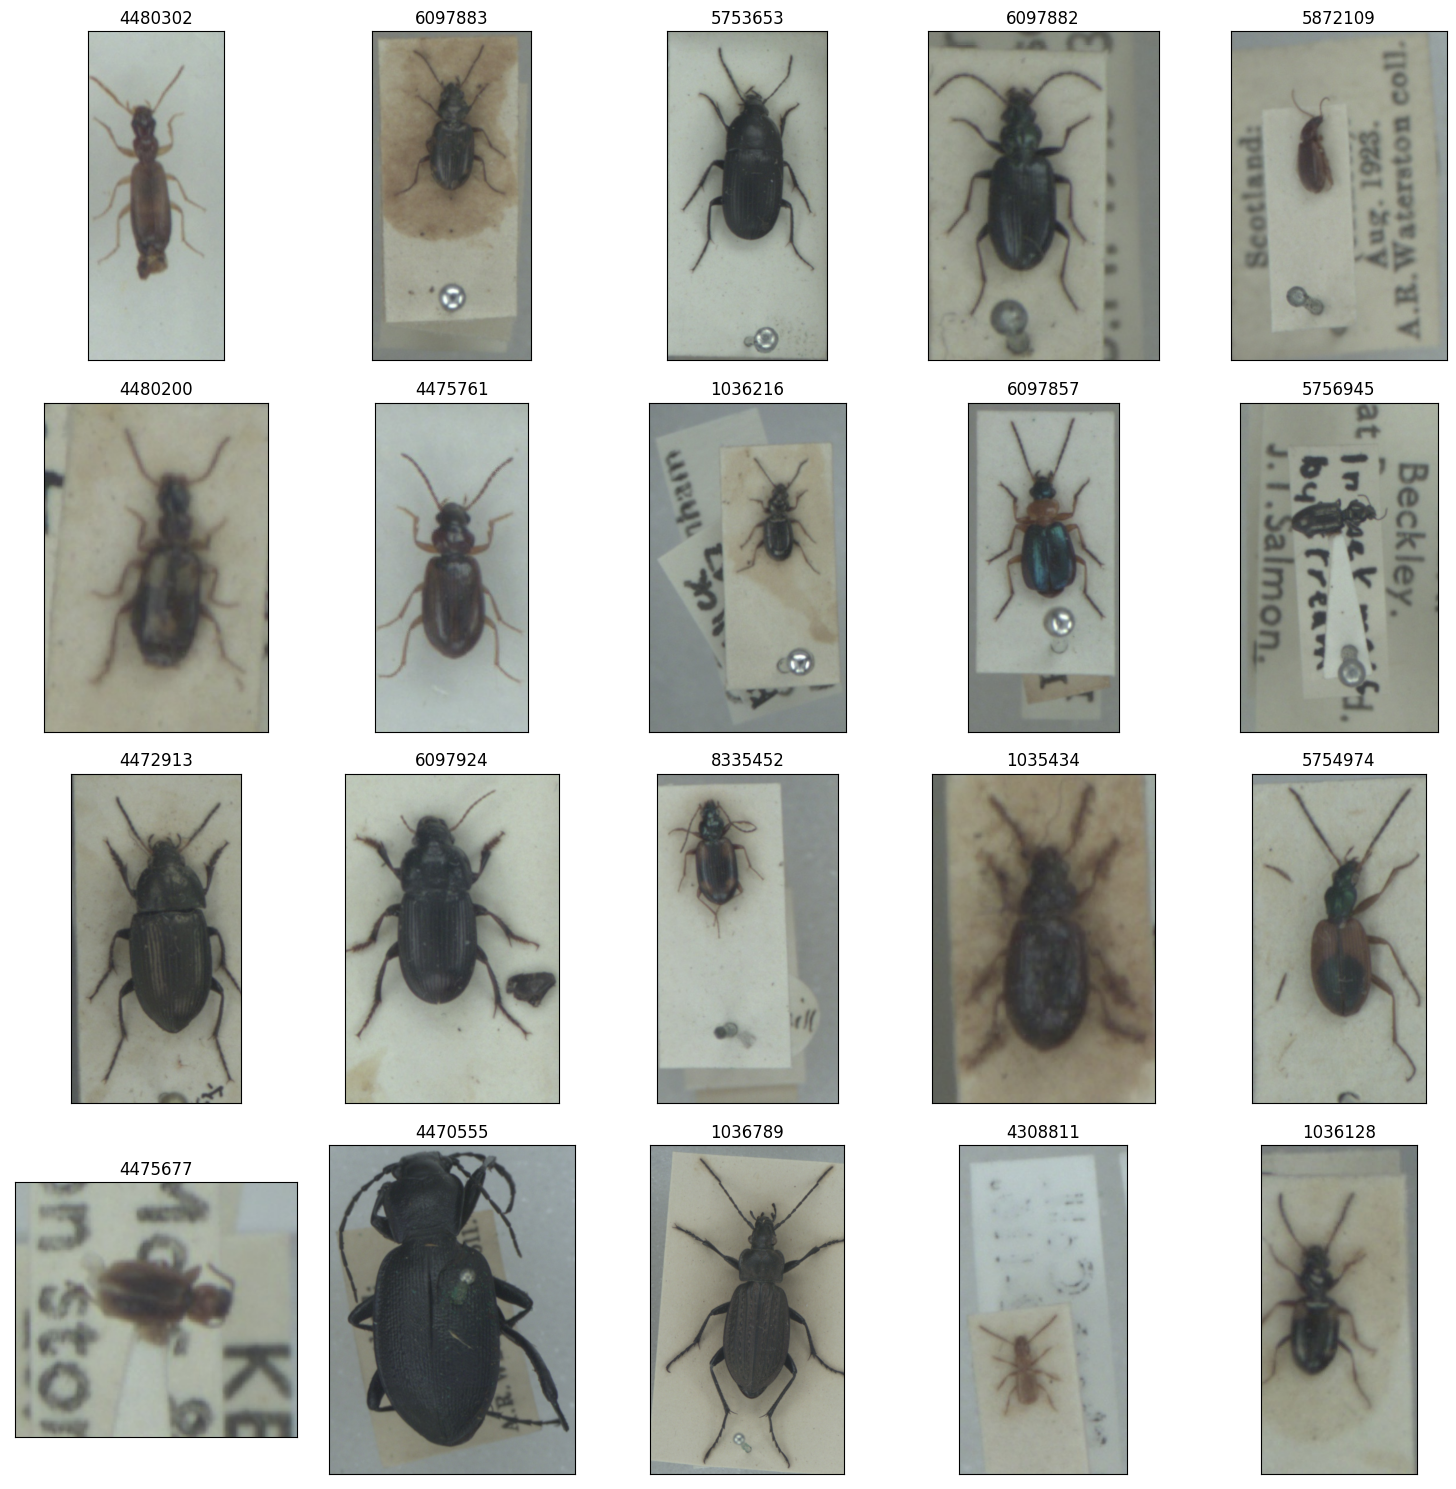

In [12]:
# Shuffle the dataset
from sklearn.utils import shuffle
df = shuffle(df, random_state = 0)
df = df.reset_index(drop=True)

# Display 20 picture of the dataset with their labels
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df.path_img[i]))
    ax.set_title(df.insect_gbif[i])
plt.tight_layout()
plt.show()

What do you observe?

All images are of differnt sizes

The backgrounsd vary a bit and as these are from a museum, there are the nals and other marks

# Image transforms using PyTorch

In [13]:
imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_tfms = T.Compose([
#this will resize the image 
    T.Resize((256,256)),   
   
#Randomly change the brightness, contrast and saturation of an image
#    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),    

#this will remove parts (crop) the Image at a random location.   
#    T.RandomCrop(32, padding=4, padding_mode='reflect'),   

#Horizontally flip (rotate by 180 degree) the given image randomly; default is 50% of images
    T.RandomHorizontalFlip(), 
    
#Rotate the image by angle -here by 10%
    T.RandomRotation(10),
    
#convert it to a tensor   
    T.ToTensor(),

#Normalize a tensor image with mean and standard deviation - here with the Imagenet stats
    T.Normalize(*imagenet_stats,inplace=True)
    
#Randomly selects a rectangle region in an image and erases its pixels.    
#    T.RandomErasing(inplace=True)
])

val_tfms = T.Compose([
#this will resize the image 
    T.Resize((256,256)),   
     
#convert it to a tensor   
    T.ToTensor(),

#Normalize a tensor image with mean and standard deviation - here with the Imagenet stats
    T.Normalize(*imagenet_stats,inplace=True)
    
])

In [14]:
class InsectDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
        
    def __len__(self):
        return len(self.df)    
    
    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img_id, img_label = row['path_img'], row['insect_gbif']
        img = Image.open(img_id)
        if self.transform:
            img = self.transform(img)
        return img, img_label

In [15]:
train_ds = InsectDataset(train,transform=train_tfms)
val_ds = InsectDataset(validate, transform=val_tfms)

In [16]:
def show_sample(img, target, invert=True):
    if invert:
        plt.imshow(1 - img.permute((1, 2, 0)))
    else:
        plt.imshow(img.permute(1, 2, 0))
    print('Labels:', target)

# View Sample Images after Transform

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Labels: 1036154


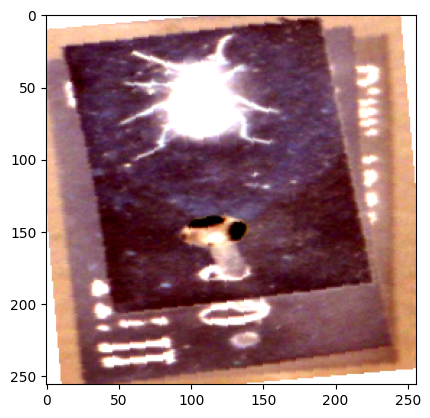

In [17]:
show_sample(*train_ds[241])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Labels: 4476667


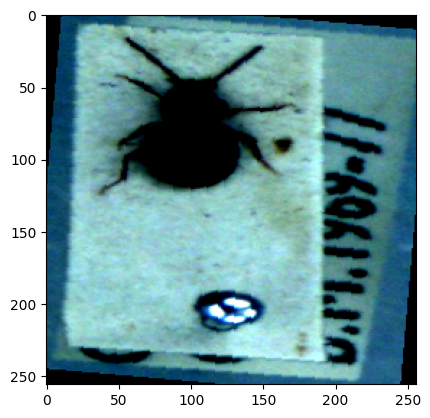

In [18]:
show_sample(*train_ds[1149], invert= False)

# Lets GO!!

Lets make an image classification model! Hope this is a good starter for you!

Thanks and all the best!